In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import odr

https://stackoverflow.com/questions/79887754/linear-regression-using-scipy-odr-gives-0-error-on-all-paramaters

In [2]:
def load_file(path):
    frame = np.loadtxt(path, skiprows=21, usecols=(2, 4, 6), max_rows=2, delimiter=",")
    return frame

In [3]:
paths = list(pathlib.Path("./data/").glob("**/*.csv"))

In [4]:
multi = np.loadtxt(paths[0], skiprows=2, delimiter=",")
multi.shape

(6, 10)

In [5]:
frames = []
for path in paths[1:]:
    frame = load_file(path)
    frames.append(frame)

In [6]:
frames = np.array(frames)
frames.shape

(30, 2, 3)

In [7]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os 
import scipy.odr
from scipy import odr

def calcurr_and_error(Voltage, Resistance, err_Voltage, err_Resistance):
    Current = Voltage/Resistance
    err_Current = Current*((err_Voltage/Voltage)**2 + (err_Resistance/Resistance)**2)**0.5
    return Current, err_Current

def Error_Vr18_multimeter(Voltage): 
    power_of_10_of_rightmost_digit = -3
    err_Vr18 = Voltage*(0.01) + 4*10**power_of_10_of_rightmost_digit # we can do this as in ALL of the readings the power of 10 is -3. thank FUCK 
    return err_Vr18

def calculate_error_on_x_value_AND_calculate_x_value(Vp, Ip, Vs, err_Vp, err_Ip, err_Vs): #not the right method for calculating uncertainties as its second order. talk about monte carlo simulations and how we dont know how do these yet in 1st year in lab report
    x = Vp*Ip / Vs 
    err_x = x*((err_Vp/Vp)**2 + (err_Ip/Ip)**2 + (err_Vs/Vs)**2)**0.5
    return x, err_x


# This one is for the ODR method because uhm i cant do weights with both the xerror and yerror 
def fit_function_linear(m_and_c_vector, x): #cuz y = mx + c
    m = m_and_c_vector[0]
    c = m_and_c_vector[1]
    output = m*x + c
    return output





r18 = 17.69 #resistances in ohms
r27 = 26.39
rprimary = 1.139
rsecondary = 0.416

err_r18 = 0.08845 
err_r27 = 0.13195
err_rprimary = 5.695e-3
err_rsecondary = 2.08e-3 # all in ohms


Vr18_array = np.loadtxt("Data/Multimeter.csv", skiprows=2, delimiter=",") 

#--- start of bit to copy paste ------------------------------------------------------------------------

Vsupply_NC = []
err_Vsupply_NC = []
Vprimary_NC = []
err_Vprimary_NC = []
Vsecondary_NC = []
err_Vsecondary_NC = []
Vr18_NC = [] #this one is the multimetre stuff which is stored in a seperate CSV 

Iprimary_NC = []
err_Iprimary_NC = []
Isecondary_NC = []
err_Isecondary_NC = []

x_values_NC = []
x_err_NC = []



i=0
num_index_of_core = 1 #index of the measurement number in the column for the Vr18, which was measured by the multimetre. ACTUALLY this is irrelevant ignore this line i dont use it
#the code for the subsequent core, and i will use this number to just get the right Vr18 values from each thing

#Doing this cuz the osilliscope saves the stats in a new CSV every time. Just change the directory and copy paste everything

directory = "Data/NC"
for dirpath, dirnames, filenames in os.walk(directory):
    for filename in filenames:
        if filename.endswith('.csv'):
            file = np.loadtxt((directory+"/"+filename), skiprows=21, usecols=(2,4,6), max_rows=2, delimiter=",")
            
            while i <= 5:
                Vr18_NC.append(Vr18_array[i, 1]) #idont think i need this 
                
                Temp_Iprimary_value, Temp_Iprimary_error = calcurr_and_error(Vr18_array[i, 1], r18, Error_Vr18_multimeter(Vr18_array[i, 1]), err_r18)
                Iprimary_NC.append(Temp_Iprimary_value)
                err_Iprimary_NC.append(Temp_Iprimary_error)
                Temp_x_value, Temp_x_error = calculate_error_on_x_value_AND_calculate_x_value(file[0,1], Temp_Iprimary_value, file[0,2], file[1,1], Temp_Iprimary_error, file[1,2])
                x_values_NC.append(Temp_x_value)
                x_err_NC.append(Temp_x_error)
                i=i+1
            
            #print(file) # this is the top right one 
            #print("")
            #print("")
            
            Vsupply_NC.append(file[0,0])
            err_Vsupply_NC.append(file[1,0])
            Vprimary_NC.append(file[0, 1])
            err_Vprimary_NC.append(file[1, 1])
            Vsecondary_NC.append(file[0,2])
            err_Vsecondary_NC.append(file[1,2])
            
            Temp_Isecondary_value, Temp_Isecondary_error = calcurr_and_error(file[0,2], r27, file[1,2], err_r27)
            
            Isecondary_NC.append(Temp_Isecondary_value)
            err_Isecondary_NC.append(Temp_Isecondary_error)

In [8]:
x_values_NC

[0.5774519074772358,
 0.7695489741857435,
 0.9442354306185555,
 1.1554841686303283,
 1.338875930200988,
 1.5483836071851913]

In [9]:
linear_model_NC = odr.Model(fit_function_linear)
Data_For_This_NC = odr.RealData(x_values_NC, Isecondary_NC, sx=x_err_NC, sy=err_Isecondary_NC)
odrThingyThatIDontReallyUnderstand_NC = odr.ODR(Data_For_This_NC, linear_model_NC, beta0=[(Temp_Isecondary_value/Temp_x_value), (Temp_Isecondary_value - (Temp_Isecondary_value/Temp_x_value))])
output_Thing_For_Fit_NC = odrThingyThatIDontReallyUnderstand_NC.run()

output_Thing_For_Fit_NC.pprint()

Beta: [ 4.60196765e-04 -1.11625606e-05]
Beta Std Error: [1.00304980e-05 9.27579183e-06]
Beta Covariance: [[ 8.14433878e-11 -7.11377156e-11]
 [-7.11377156e-11  6.96486692e-11]]
Residual Variance: 1.235347566470866
Inverse Condition #: 0.1559416360050621
Reason(s) for Halting:
  Sum of squares convergence


In [10]:
print(err_Isecondary_NC)

[1.8475760684456049e-06, 2.3068179242477337e-06, 2.9269207902671022e-06, 3.216100984520936e-06, 3.5976260067040303e-06, 4.199589342004377e-06]


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr

In [12]:
x = [0.5774519074772358, 0.7695489741857435, 0.9442354306185555, 1.1554841686303283, 1.338875930200988, 1.5483836071851913]
y = [0.0002572603258810155, 0.0003410382720727548, 0.00042440318302387265, 0.0005077680939749906, 0.0006025009473285336, 0.0007161803713527852]
sx = [0.009165815852678103, 0.01153852030387432, 0.01370277709838041, 0.016324732752096453, 0.01860353171584009, 0.02120875049759542]
sy = [1.8475760684456049e-06, 2.3068179242477337e-06, 2.9269207902671022e-06, 3.216100984520936e-06, 3.5976260067040303e-06, 4.199589342004377e-06]

In [13]:
def function(beta, x):
    return beta[0] * x + beta[1]

In [14]:
model = odr.Model(function)
dataset = odr.RealData(x, y, sx=sx, sy=sy)
solver = odr.ODR(dataset, model, beta0=[0., 0.])
solution = solver.run()

In [15]:
solution.pprint()

Beta: [ 4.60196815e-04 -1.11626079e-05]
Beta Std Error: [1.00309754e-05 9.27629786e-06]
Beta Covariance: [[ 8.14511392e-11 -7.11453883e-11]
 [-7.11453883e-11  6.96562686e-11]]
Residual Variance: 1.2353475664687967
Inverse Condition #: 0.15593394719372533
Reason(s) for Halting:
  Sum of squares convergence


In [16]:
xlin = np.linspace(x[0], x[-1], 200)
yhat = function(solution.beta, xlin)

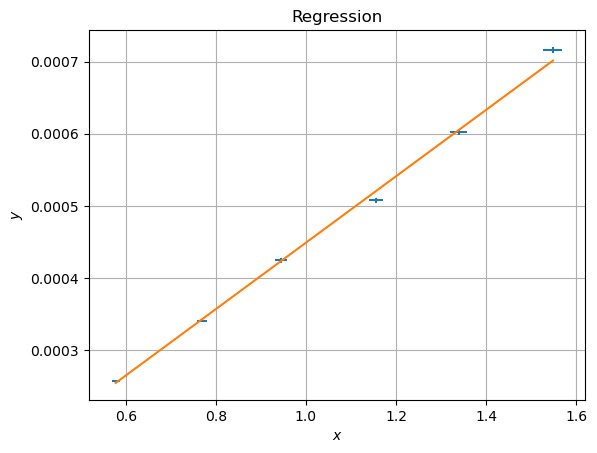

In [18]:
fig, axe = plt.subplots()
axe.errorbar(x, y, xerr=sx, yerr=sy, linestyle="none")
axe.plot(xlin, yhat)
axe.set_title("Regression")
axe.set_xlabel("$x$")
axe.set_ylabel("$y$")
axe.grid()